# NARR–PRISM Phase-2 stochastic residual refinement

This parameterized notebook is the NARR–PRISM front end for all four refinement heads: diffusion UNet, diffusion Transformer, flow-matching UNet, and flow-matching Transformer. It follows the Phase-1/Phase-2 structure of `SA_downscaling_refinement_T2_ACCESS-CM2_static.ipynb`, while delegating working training and inference to shared repository code.

> **Scientific-use boundary:** `SMOKE_TEST=True` uses a tiny synthetic fixture only to check implementation mechanics. Its fields and metrics are not NARR–PRISM validation and must not be presented as scientific skill. Production mode never substitutes synthetic data or weights.

## 1. Environment and repository paths

Run this notebook with the existing `Prithvi` mamba environment. No package installation or environment mutation is performed here.

In [1]:
import codecs
import gc
import json
import os
import random
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import torch
import yaml

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Run the notebook from within the granite-wxc repository.')
NARR_PRISM_DIR = REPO_ROOT / 'examples' / 'NARR_PRISM'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NARR_PRISM_DIR) not in sys.path:
    sys.path.insert(0, str(NARR_PRISM_DIR))

def run_streaming_command(
    command, *, cwd, log_dir=None, tail_bytes=65536, progress_factory=None
):
    """Stream a CLI, rendering child tqdm records as log-friendly text bars."""
    if tail_bytes <= 0:
        raise ValueError('tail_bytes must be positive')
    command = [str(part) for part in command]
    log_root = Path(log_dir) if log_dir is not None else Path(cwd) / '.narr_prism_command_logs'
    log_root.mkdir(parents=True, exist_ok=True)
    script_parts = [part for part in command[1:] if part.endswith('.py')]
    command_name = Path(script_parts[0] if script_parts else command[0]).stem
    safe_name = ''.join(character if character.isalnum() or character in '-_' else '_' for character in command_name)
    log_path = log_root / f'{safe_name}-{os.getpid()}-{time.time_ns()}.log'
    print(f'Command output log: {log_path}', flush=True)
    child_env = dict(os.environ)
    child_env['PYTHONUNBUFFERED'] = '1'
    retained_tail = bytearray()
    if progress_factory is None:
        from tqdm import tqdm as progress_factory
    regex = __import__('re')
    ansi_pattern = regex.compile(r'\x1b\[[0-?]*[ -/]*[@-~]')
    tqdm_pattern = regex.compile(
        r'^(?P<description>.*?):\s*(?P<percent>\d{1,3})%\|.*\|\s*'
        r'(?P<current>[\d,]+)/(?P<total>[\d,]+)(?:\s|\[)'
    )
    stream_buffer = ''
    active_progress = None
    active_progress_key = None
    active_progress_value = 0

    def close_progress():
        nonlocal active_progress, active_progress_key, active_progress_value
        if active_progress is not None:
            active_progress.close()
        active_progress = None
        active_progress_key = None
        active_progress_value = 0

    def render_record(record, separator):
        nonlocal progress_factory, active_progress, active_progress_key
        nonlocal active_progress_value
        clean_record = ansi_pattern.sub('', record)
        if not record and separator == '\r' and progress_factory is not None:
            return
        match = tqdm_pattern.match(clean_record)
        if match is not None and progress_factory is not None:
            description = match.group('description').strip()
            current = int(match.group('current').replace(',', ''))
            total = int(match.group('total').replace(',', ''))
            progress_key = (description, total)
            if active_progress_key != progress_key:
                close_progress()
                unit = 'batch' if description.startswith(('Epoch ', 'Residual-')) else 'day'
                try:
                    active_progress = progress_factory(
                        total=total, desc=description, unit=unit, leave=True,
                        file=sys.stdout, ascii=True, dynamic_ncols=False,
                    )
                except Exception as exc:
                    progress_factory = None
                    print(
                        f'Text tqdm renderer unavailable ({exc}); forwarding child progress.',
                        file=sys.stderr, flush=True,
                    )
                    sys.stdout.write(record + separator)
                    sys.stdout.flush()
                    return
                active_progress_key = progress_key
                active_progress_value = 0
            if current < active_progress_value:
                active_progress.reset(total=total)
                active_progress_value = 0
            if current > active_progress_value:
                active_progress.update(current - active_progress_value)
                active_progress_value = current
            postfix_match = regex.search(
                r'((?:stage|train_loss|val_loss|lr)=[^]]+)', clean_record
            )
            if postfix_match is not None:
                active_progress.set_postfix_str(postfix_match.group(1), refresh=True)
            if separator == '\n' and current >= total:
                close_progress()
            return
        sys.stdout.write(record + separator)
        sys.stdout.flush()

    def render_stream(rendered_text, final=False):
        nonlocal stream_buffer
        stream_buffer += rendered_text
        while True:
            carriage = stream_buffer.find('\r')
            newline = stream_buffer.find('\n')
            positions = [position for position in (carriage, newline) if position >= 0]
            if not positions:
                break
            position = min(positions)
            separator = stream_buffer[position]
            record = stream_buffer[:position]
            stream_buffer = stream_buffer[position + 1:]
            render_record(record, separator)
        if final and stream_buffer:
            render_record(stream_buffer, '')
            stream_buffer = ''

    with log_path.open('wb') as log_stream:
        process = subprocess.Popen(
            command, cwd=cwd, env=child_env, bufsize=0,
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        )
        if process.stdout is None:
            process.kill()
            process.wait()
            raise RuntimeError(
                f'Could not capture the subprocess output stream; log: {log_path}'
            )
        decoder = codecs.getincrementaldecoder('utf-8')(errors='replace')
        try:
            while True:
                chunk = os.read(process.stdout.fileno(), 4096)
                if not chunk:
                    break
                log_stream.write(chunk)
                log_stream.flush()
                retained_tail.extend(chunk)
                if len(retained_tail) > tail_bytes:
                    del retained_tail[:-tail_bytes]
                rendered = decoder.decode(chunk)
                if rendered:
                    render_stream(rendered)
            rendered = decoder.decode(b'', final=True)
            if rendered:
                render_stream(rendered)
            render_stream('', final=True)
            close_progress()
            return_code = process.wait()
        except BaseException:
            render_stream('', final=True)
            close_progress()
            if process.poll() is None:
                process.terminate()
                try:
                    process.wait(timeout=5)
                except subprocess.TimeoutExpired:
                    process.kill()
                    process.wait()
            print(f'Command interrupted; retained output: {log_path}', file=sys.stderr, flush=True)
            raise
    if return_code:
        tail = retained_tail.decode('utf-8', errors='replace')
        class StreamingCommandError(subprocess.CalledProcessError):
            def __str__(self):
                detail = super().__str__()
                tail_detail = self.output.rstrip() or '<no child output was captured>'
                return f'{detail}\nFull command output: {self.log_path}\nRetained output tail:\n{tail_detail}'
        error = StreamingCommandError(return_code, command, output=tail)
        error.log_path = log_path
        raise error
    return subprocess.CompletedProcess(command, return_code)
print(f'Repository: {REPO_ROOT}')
print(f'Python: {sys.executable}')
print(f'Torch: {torch.__version__}; CUDA available: {torch.cuda.is_available()}')

Repository: /data/granite-wxc
Python: /home/azureuser/miniforge3/envs/Prithvi/bin/python
Torch: 2.12.0+cu130; CUDA available: True


## 2. Configuration selection and reproducibility

Edit `REFINEMENT_CONFIG` to switch heads. The checked-in default is the Diffusion Transformer and production residual-head training is enabled by default. `SMOKE_TEST` remains false unless explicitly requested by CI; enabling it automatically disables the production-training default. `PREDICTION_SPLIT` selects the held-out `validation` dates or the later `inference` dates; validation is the default for scientific comparison. `REFINEMENT_CHECKPOINT` is required for standalone production prediction, but may remain unset for a combined training-and-inference run because that run selects its newly written checkpoint. `RESUME_FROM_CHECKPOINT=True` resumes Phase 2 without reinitializing either phase. The default Phase-1 checkpoint is reached through the repository's validated local artifact portal. Checkpoints use the selected YAML's per-head `checkpoint_dir`; `NARR_PRISM_REFINEMENT_CHECKPOINT_DIR` can override it. Other outputs use a separate config-derived directory under `examples/NARR_PRISM/refinement_outputs/`, preventing one head from overwriting another. Override this with `NARR_PRISM_REFINEMENT_OUTPUT_DIR` when needed.

In [2]:
def _env_flag(name, default=False):
    return os.environ.get(name, str(int(default))).strip().lower() in {'1', 'true', 'yes', 'on'}

# ========================== USER PARAMETERS ==========================
REFINEMENT_CONFIG = os.environ.get(
    'NARR_PRISM_REFINEMENT_CONFIG',
    'examples/NARR_PRISM/NARR_PRISM_diffusion_transformer.yaml',
)
PHASE1_CHECKPOINT = os.environ.get(
    'NARR_PRISM_PHASE1_CHECKPOINT',
    'examples/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt',
)
REFINEMENT_CHECKPOINT = os.environ.get('NARR_PRISM_REFINEMENT_CHECKPOINT') or None
REFINEMENT_CHECKPOINT_DIR = (
    os.environ.get('NARR_PRISM_REFINEMENT_CHECKPOINT_DIR') or None
)
RESUME_CHECKPOINT = os.environ.get('NARR_PRISM_RESUME_CHECKPOINT') or None
ENSEMBLE_SIZE = int(os.environ.get('NARR_PRISM_ENSEMBLE_SIZE', '10'))
SMOKE_TEST = _env_flag('NARR_PRISM_SMOKE_TEST', False)
PREDICTION_SPLIT = os.environ.get(
    'NARR_PRISM_PREDICTION_SPLIT', 'validation'
).strip().lower()
if PREDICTION_SPLIT not in {'validation', 'inference'}:
    raise ValueError(
        'NARR_PRISM_PREDICTION_SPLIT must be validation or inference, '
        f'got {PREDICTION_SPLIT!r}'
    )
DEFAULT_OUTPUT_DIR = str(
    Path('examples/NARR_PRISM/refinement_outputs')
    / Path(REFINEMENT_CONFIG).stem
)
OUTPUT_DIR = os.environ.get(
    'NARR_PRISM_REFINEMENT_OUTPUT_DIR', DEFAULT_OUTPUT_DIR
)
PHASE1_DAILY_DIR = os.environ.get(
    'NARR_PRISM_PHASE1_DAILY_DIR',
    (
        'examples/NARR_PRISM/experiments/inference_output/validation/'
        'narr_prism_California'
        if PREDICTION_SPLIT == 'validation'
        else 'examples/NARR_PRISM/experiments/inference_output/'
        'narr_prism_California'
    ),
)
SEED = int(os.environ.get('NARR_PRISM_REFINEMENT_SEED', '1234'))
DEVICE = os.environ.get(
    'NARR_PRISM_REFINEMENT_DEVICE', 'cuda:0' if torch.cuda.is_available() else 'cpu'
)
# A normal Run All trains the selected residual-refinement head. Explicit
# smoke mode is reserved for CI and defaults production training back off.
RUN_TRAINING = _env_flag('NARR_PRISM_RUN_TRAINING', not SMOKE_TEST)
RUN_INFERENCE = _env_flag('NARR_PRISM_RUN_INFERENCE', False)
RUN_EVALUATION = _env_flag('NARR_PRISM_RUN_EVALUATION', False)
RESUME_FROM_CHECKPOINT = _env_flag('NARR_PRISM_RESUME', False)
AUTO_RESUME_EXISTING = _env_flag('NARR_PRISM_AUTO_RESUME', True)
FRESH_START = _env_flag('NARR_PRISM_FRESH_START', False)
if FRESH_START and RESUME_FROM_CHECKPOINT:
    raise ValueError('NARR_PRISM_FRESH_START conflicts with NARR_PRISM_RESUME')
BUILD_PHASE1_CACHE_IF_MISSING = _env_flag(
    'NARR_PRISM_BUILD_PHASE1_CACHE_IF_MISSING', True
)
WAIT_FOR_ACTIVE_PHASE1_CACHE = _env_flag(
    'NARR_PRISM_WAIT_FOR_ACTIVE_PHASE1_CACHE', True
)
PHASE1_CACHE_WAIT_POLL_SECONDS = float(
    os.environ.get('NARR_PRISM_PHASE1_CACHE_WAIT_POLL_SECONDS', '60')
)
if PHASE1_CACHE_WAIT_POLL_SECONDS <= 0:
    raise ValueError('NARR_PRISM_PHASE1_CACHE_WAIT_POLL_SECONDS must be positive')
_cache_gpu_override = os.environ.get('NARR_PRISM_PHASE1_CACHE_PARALLEL_GPUS')
if _cache_gpu_override is None:
    _visible_gpu_tokens = (
        os.environ.get('CUDA_VISIBLE_DEVICES', '').strip()
    )
    PHASE1_CACHE_PARALLEL_GPUS = (
        _visible_gpu_tokens
        if torch.cuda.device_count() > 1 and _visible_gpu_tokens
        else (
            ','.join(str(index) for index in range(torch.cuda.device_count()))
            if torch.cuda.device_count() > 1 else None
        )
    )
elif _cache_gpu_override.strip().lower() in {'', 'none', 'single'}:
    PHASE1_CACHE_PARALLEL_GPUS = None
else:
    PHASE1_CACHE_PARALLEL_GPUS = _cache_gpu_override.strip()
# =====================================================================

def repo_path(value):
    path = Path(value).expanduser()
    return path if path.is_absolute() else REPO_ROOT / path

CONFIG_PATH = repo_path(REFINEMENT_CONFIG)
PHASE1_PATH = repo_path(PHASE1_CHECKPOINT)
REFINEMENT_PATH = repo_path(REFINEMENT_CHECKPOINT) if REFINEMENT_CHECKPOINT else None
RESUME_PATH = repo_path(RESUME_CHECKPOINT) if RESUME_CHECKPOINT else None
OUTPUT_PATH = repo_path(OUTPUT_DIR)
try:
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
except OSError as exc:
    raise RuntimeError(
        f'Cannot create refinement output directory {OUTPUT_PATH}: {exc}. '
        'Set NARR_PRISM_REFINEMENT_OUTPUT_DIR to a writable directory. '
        'If the selected path traverses examples/NARR_PRISM/experiments, '
        'repair or remount that artifact path first; it must not point to itself.'
    ) from exc
PHASE1_DAILY_PATH = repo_path(PHASE1_DAILY_DIR)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(json.dumps({
    'config': str(CONFIG_PATH), 'phase1_checkpoint': str(PHASE1_PATH),
    'refinement_checkpoint': str(REFINEMENT_PATH) if REFINEMENT_PATH else None,
    'resume_checkpoint': str(RESUME_PATH) if RESUME_PATH else None,
    'ensemble_size': ENSEMBLE_SIZE, 'smoke_test': SMOKE_TEST,
    'prediction_split': PREDICTION_SPLIT,
    'output_dir': str(OUTPUT_PATH), 'seed': SEED, 'device': DEVICE,
    'phase1_daily_dir': str(PHASE1_DAILY_PATH),
    'run_training': RUN_TRAINING, 'run_inference': RUN_INFERENCE,
    'run_evaluation': RUN_EVALUATION,
    'resume_requested': RESUME_FROM_CHECKPOINT,
    'auto_resume_existing': AUTO_RESUME_EXISTING,
    'fresh_start': FRESH_START,
    'build_phase1_cache_if_missing': BUILD_PHASE1_CACHE_IF_MISSING,
    'wait_for_active_phase1_cache': WAIT_FOR_ACTIVE_PHASE1_CACHE,
    'phase1_cache_wait_poll_seconds': PHASE1_CACHE_WAIT_POLL_SECONDS,
    'phase1_cache_parallel_gpus': PHASE1_CACHE_PARALLEL_GPUS,
}, indent=2))

{
  "config": "/data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_diffusion_transformer.yaml",
  "phase1_checkpoint": "/data/granite-wxc/examples/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt",
  "refinement_checkpoint": null,
  "resume_checkpoint": null,
  "ensemble_size": 10,
  "smoke_test": false,
  "prediction_split": "validation",
  "output_dir": "/data/granite-wxc/examples/NARR_PRISM/refinement_outputs/NARR_PRISM_diffusion_transformer",
  "seed": 1234,
  "device": "cuda:0",
  "phase1_daily_dir": "/data/granite-wxc/examples/NARR_PRISM/experiments/inference_output/validation/narr_prism_California",
  "run_training": true,
  "run_inference": false,
  "run_evaluation": false,
  "resume_requested": false,
  "auto_resume_existing": true,
  "fresh_start": false,
  "build_phase1_cache_if_missing": true,
  "wait_for_active_phase1_cache": true,
  "phase1_cache_wait_poll_seconds": 60.0,
  "phase1_cache_parallel_gpus": "0,1,2,3"
}


## 3. Configuration and checkpoint compatibility checks

The selected YAML is parsed through the shared schema. Production mode requires the real Phase-1 checkpoint and never falls back to random or synthetic weights. The shared CLI performs the detailed tensor and pipeline-contract checks when it loads the model.

In [3]:
from granitewxc.refinement.config import resolve_refinement_config
from granitewxc.utils.config import get_config
from narr_prism_artifacts import ArtifactLinkError, validate_artifact_links

if not CONFIG_PATH.is_file():
    raise FileNotFoundError(f'Refinement YAML not found: {CONFIG_PATH}')
raw_config = yaml.safe_load(CONFIG_PATH.read_text())
config = get_config(str(CONFIG_PATH))
refinement = resolve_refinement_config(config)
output_variables = list(config.data.output_vars)
if output_variables != ['ppt', 'tmax', 'tmin']:
    raise ValueError(f'Unexpected NARR–PRISM output order: {output_variables}')
if not refinement.is_active:
    raise ValueError('The selected configuration does not enable Phase-2 refinement.')
if RUN_TRAINING and not SMOKE_TEST:
    residual_head_only = (
        refinement.train_on_residual
        and refinement.freeze_phase1
        and not refinement.joint_finetuning
        and not refinement.trainable_phase1_patterns
    )
    if not residual_head_only:
        raise ValueError(
            'This notebook is configured for residual-refinement-head-only training: '
            'require train_on_residual=true, freeze_phase1=true, '
            'joint_finetuning=false, and no trainable_phase1_patterns.'
        )

artifact_status = None
if not SMOKE_TEST:
    try:
        artifact_status = validate_artifact_links(NARR_PRISM_DIR)
    except ArtifactLinkError as exc:
        raise RuntimeError(
            f'NARR–PRISM artifact links are not usable: {exc}'
        ) from exc
    print(json.dumps({'artifact_links': artifact_status}, indent=2))

describe_command = [
    sys.executable, str(NARR_PRISM_DIR / 'narr_prism_refinement.py'), 'describe',
    '--config', str(CONFIG_PATH), '--phase1-checkpoint', str(PHASE1_PATH),
]
subprocess.run(describe_command, cwd=REPO_ROOT, check=True)

if not SMOKE_TEST:
    try:
        phase1_exists = PHASE1_PATH.is_file()
    except OSError as exc:
        raise FileNotFoundError(f'Cannot access Phase-1 checkpoint {PHASE1_PATH}: {exc}') from exc
    if not phase1_exists:
        artifact_root = artifact_status['artifact_root'] if artifact_status else None
        raise FileNotFoundError(
            f'Production mode requires the real Phase-1 checkpoint: {PHASE1_PATH}. '
            f'The artifact portal is valid and resolves to {artifact_root}, but the '
            'checkpoint file is absent there. Verify the selected artifact copy or set '
            'NARR_PRISM_PHASE1_CHECKPOINT to another compatible last.ckpt. '
            'Use SMOKE_TEST=True only for the explicitly synthetic mechanics check.'
        )
    if RUN_INFERENCE and REFINEMENT_PATH is not None and not REFINEMENT_PATH.is_file():
        raise FileNotFoundError(
            f'REFINEMENT_CHECKPOINT is not accessible: {REFINEMENT_PATH}'
        )
    if RUN_INFERENCE and not RUN_TRAINING and REFINEMENT_PATH is None:
        raise FileNotFoundError(
            'Standalone RUN_INFERENCE requires an existing REFINEMENT_CHECKPOINT. '
            'A combined RUN_TRAINING + RUN_INFERENCE execution may leave it unset; '
            'the notebook will select the new best.ckpt, then last.ckpt.'
        )
print(f'Active head: {refinement.type}; output order: {output_variables}')
if RUN_TRAINING and not SMOKE_TEST:
    print(
        'Production training enabled: normalized PRISM-minus-Phase1 residual; '
        'Phase 1 frozen; refinement head trainable.'
    )

{
  "artifact_links": {
    "narr_prism_dir": "/data/granite-wxc/examples/NARR_PRISM",
    "artifact_root": "/data2/granite-wxc-artifacts/NARR_PRISM",
    "configured": true,
    "links": {
      "experiments": "/data2/granite-wxc-artifacts/NARR_PRISM/experiments",
      "preprocessed": "/data2/granite-wxc-artifacts/NARR_PRISM/preprocessed",
      "scalars_with_H": "/data2/granite-wxc-artifacts/NARR_PRISM/scalars_with_H"
    }
  }
}


{
  "refinement": {
    "enabled": true,
    "type": "diffusion_transformer",
    "checkpoint": null,
    "freeze_phase1": true,
    "joint_finetuning": false,
    "train_on_residual": true,
    "ensemble_size": 10,
    "loss": "mse",
    "seed": 1234,
    "trainable_phase1_patterns": [],
    "correction_scale": 1.0,
    "conditioning": {
      "deterministic_output": true,
      "input_predictors": true,
      "prithvi_features": false,
      "unet_features": false,
      "static_fields": false,
      "masks": false,
      "coordinates": true
    },
    "residual_normalization": {
      "enabled": true,
      "epsilon": 1e-06,
      "fit_batches": 0
    },
    "auxiliary_loss": {
      "reconstruction_weight": 0.1,
      "reconstruction_loss": "huber",
      "bias_weight": 0.02,
      "gradient_weight": 0.05,
      "laplacian_weight": 0.01,
      "multiscale_weight": 0.02,
      "tail_weight": 0.02,
      "tail_threshold": 2.0,
      "variable_weights": [
        1.0,
        1.0,
   

Active head: diffusion_transformer; output order: ['ppt', 'tmax', 'tmin']
Production training enabled: normalized PRISM-minus-Phase1 residual; Phase 1 frozen; refinement head trainable.


## 4. Dataset, dates, normalization, units, and grid inspection

These values are displayed before any training. Residual statistics must be fitted only from the configured training split. The held-out validation dates are used for model comparison; the later inference dates are a distinct prediction period. Neither prediction split is used to fit normalization or residual statistics.

In [4]:
data_summary = {
    'case_name': raw_config.get('case_name'),
    'input_vars': raw_config['data'].get('input_vars', []),
    'output_vars': raw_config['data'].get('output_vars', []),
    'target_variables': raw_config['data'].get('target_variables', []),
    'dates': raw_config.get('dates', {}),
    'spatial_subset': raw_config['data'].get('spatial_subset', {}),
    'crop': [raw_config['data'].get('train_crop_size_lat'), raw_config['data'].get('train_crop_size_lon')],
    'stride': [raw_config['data'].get('training_tile_stride_lat'), raw_config['data'].get('training_tile_stride_lon')],
    'halo': [raw_config['data'].get('training_halo_lat'), raw_config['data'].get('training_halo_lon')],
    'normalization': raw_config.get('normalization', {}),
    'predictands': raw_config.get('predictands', {}),
    'physical_units': {'ppt': 'mm/day', 'tmax': 'degC', 'tmin': 'degC'},
}
print(json.dumps(data_summary, indent=2))

{
  "case_name": "narr_prism_California",
  "input_vars": [
    "shum_500",
    "shum_700",
    "shum_850",
    "uwnd_500",
    "uwnd_700",
    "uwnd_850",
    "vwnd_500",
    "vwnd_700",
    "vwnd_850",
    "air_500",
    "air_700",
    "air_850",
    "hgt_500",
    "hgt_700",
    "hgt_850",
    "elev",
    "mask_shum_500",
    "mask_shum_700",
    "mask_shum_850",
    "mask_uwnd_500",
    "mask_uwnd_700",
    "mask_uwnd_850",
    "mask_vwnd_500",
    "mask_vwnd_700",
    "mask_vwnd_850",
    "mask_air_500",
    "mask_air_700",
    "mask_air_850",
    "mask_hgt_500",
    "mask_hgt_700",
    "mask_hgt_850",
    "mask_elev"
  ],
  "output_vars": [
    "ppt",
    "tmax",
    "tmin"
  ],
  "target_variables": [
    "ppt",
    "tmax",
    "tmin"
  ],
  "dates": {
    "training": {
      "start": "1996-01-01",
      "end": "2013-12-31"
    },
    "validation": {
      "start": "2014-01-01",
      "end": "2015-12-31"
    },
    "inference": {
      "start": "2016-01-01",
      "end": "2025-1

## 5. Load and freeze Phase 1; inspect a deterministic baseline batch and residual target

Production inspection calls the same shared data/model builders as the CLI. It checks the frozen parameter state, runs one deterministic batch, and constructs the exact normalized residual target.

In [5]:
model = None
train_loader = None
validation_loader = None
phase1_fingerprint = None
baseline_batch = None
baseline_output = None
baseline_normalized = None
phase1_features = None
baseline_residual = None
baseline_valid = None
valid_residual = None
baseline_residual_statistics = None
model_description = None
if not SMOKE_TEST:
    from narr_prism_refinement import build_model
    from narr_prism_training import get_dataloaders

    train_loader, validation_loader = get_dataloaders(str(CONFIG_PATH), config)
    baseline_batch = next(iter(train_loader))
    baseline_batch = {
        key: value.to(DEVICE) if torch.is_tensor(value) else value
        for key, value in baseline_batch.items()
    }
    model, phase1_fingerprint = build_model(
        config, str(CONFIG_PATH), str(PHASE1_PATH), torch.device(DEVICE)
    )
    model.initialize_from_batch(baseline_batch).eval()
    if not model.phase1_frozen or any(p.requires_grad for p in model.phase1.parameters()):
        raise RuntimeError('Phase 1 is not completely frozen in the default Phase-2 mode.')
    with torch.no_grad():
        baseline_output, baseline_normalized, phase1_features = model.run_phase1(baseline_batch)
        baseline_residual, baseline_valid = model.target_space.residual_target(
            baseline_batch['y'], baseline_normalized,
            scaler_offset=baseline_batch.get('__output_scaler_offset', baseline_batch.get('__scaler_offset')),
        )
    model_description = model.describe()
    print(model_description)
    print(f'x={tuple(baseline_batch["x"].shape)}, y={tuple(baseline_batch["y"].shape)}')
    print(f'residual valid fraction={float(baseline_valid.float().mean()):.6f}')
else:
    print('Production Phase-1 loading skipped: explicit synthetic smoke mode is active.')

[dataset] strict preprocessed source: /data2/granite-wxc-artifacts/NARR_PRISM/preprocessed/narr_prism_California/training (6575 required daily products; raw fallback disabled)
[dataset] canonical PRISM grid fingerprint=f062e76bd115
[dataset] deterministic training tiles: 5x5=25 candidate, 22 kept, tile=(256, 256), stride=(192, 192), halo=(32, 32)
[dataset] strict preprocessed source: /data2/granite-wxc-artifacts/NARR_PRISM/preprocessed/narr_prism_California/validation (730 required daily products; raw fallback disabled)
[dataset] canonical PRISM grid fingerprint=f062e76bd115
[dataset] deterministic training tiles: 5x5=25 candidate, 22 kept, tile=(256, 256), stride=(192, 192), halo=(32, 32)


[dataset] predictor->PRISM alignment OK: strict preprocessed product is on the canonical target grid (320, 320) before tiling.
[dataset] predictor->PRISM alignment OK: strict preprocessed product is on the canonical target grid (320, 320) before tiling.


[refinement] Using case_name: narr_prism_California
[refinement] Using preprocessing directory: /data2/granite-wxc-artifacts/NARR_PRISM/preprocessed/narr_prism_California
[refinement] Using scalar directory: /data2/granite-wxc-artifacts/NARR_PRISM/preprocessed/narr_prism_California/scalars
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[model] predictand configuration:
  - ppt: scaling=divide_only
  - tmax: scaling=zscore
  - tmin: scaling=zscore
Creating the model.
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.


[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 246,452,746 params.


[model] loaded 12 tensors, skipped 196
[refinement] loading Phase-1 checkpoint (read-only): /data2/granite-wxc-artifacts/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt


/data/granite-wxc/granitewxc/utils/prism_checkpoint.py:426: RuntimeWarning: [NARR refinement Phase-1 load:schema4-source-rebind] accepted attested PRISM source-device rebind 5588ce4c394f->3e41bdcc95f9 using /data2/granite-wxc-artifacts/NARR_PRISM/preprocessed/narr_prism_California/scalars/phase1_source_rebind.json attestation_sha256=ffef6674e51c3cfadbea79f86b4a7771fbf83c8165e1a0639551a39e9f3b171f
  validate_phase1_source_rebind_attestation(


[refinement] Phase-1 load: loaded=208 missing=0 unexpected=0 shape_mismatched=0 renamed=208


[refinement] Phase-1 fingerprint: 84c8509ce161f049d8999e5d44b43b83d36cc316a579d052df1bd0f6173a31c7


/home/azureuser/miniforge3/envs/Prithvi/lib/python3.14/contextlib.py:109: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


{'refinement': {'enabled': True, 'type': 'diffusion_transformer', 'checkpoint': None, 'freeze_phase1': True, 'joint_finetuning': False, 'train_on_residual': True, 'ensemble_size': 10, 'loss': 'mse', 'seed': 1234, 'trainable_phase1_patterns': [], 'correction_scale': 1.0, 'conditioning': {'deterministic_output': True, 'input_predictors': True, 'prithvi_features': False, 'unet_features': False, 'static_fields': False, 'masks': False, 'coordinates': True}, 'residual_normalization': {'enabled': True, 'epsilon': 1e-06, 'fit_batches': 0}, 'auxiliary_loss': {'reconstruction_weight': 0.1, 'reconstruction_loss': 'huber', 'bias_weight': 0.02, 'gradient_weight': 0.05, 'laplacian_weight': 0.01, 'multiscale_weight': 0.02, 'tail_weight': 0.02, 'tail_threshold': 2.0, 'variable_weights': [1.0, 1.0, 1.0]}, 'diffusion': {'training_timesteps': 1000, 'inference_steps': 50, 'prediction_type': 'epsilon', 'schedule': 'cosine', 'beta_start': 0.0001, 'beta_end': 0.02, 'cosine_s': 0.008, 'clip_sample': False, 'c

{'mean': 0.03751390054821968, 'std': 0.39835894107818604, 'min': -3.1974940299987793, 'max': 2.3264389038085938}


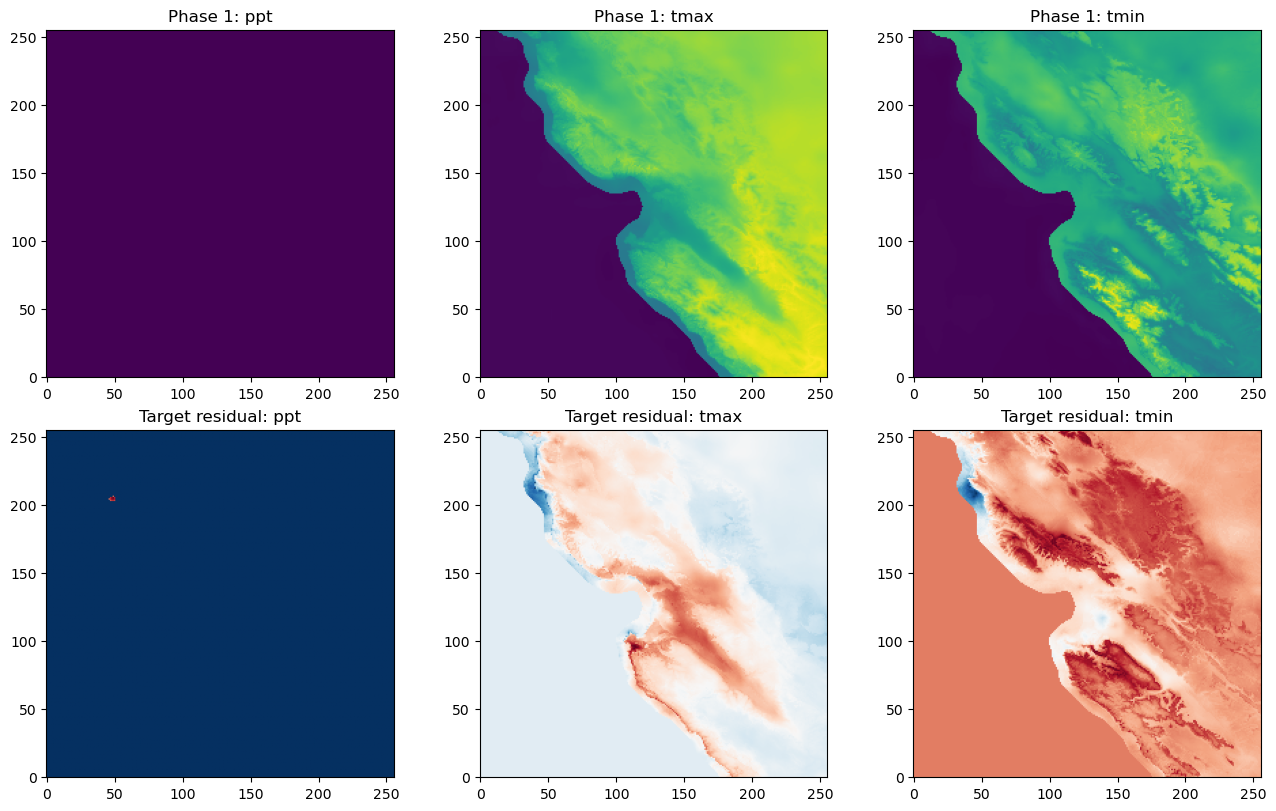

In [6]:
if baseline_residual is not None:
    import matplotlib.pyplot as plt

    valid_residual = baseline_residual[baseline_valid]
    baseline_residual_statistics = {
        'mean': float(valid_residual.mean()), 'std': float(valid_residual.std()),
        'min': float(valid_residual.min()), 'max': float(valid_residual.max()),
    }
    print(baseline_residual_statistics)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
    for index, name in enumerate(output_variables):
        axes[0, index].imshow(baseline_output[0, index].detach().cpu(), origin='lower')
        axes[0, index].set_title(f'Phase 1: {name}')
        axes[1, index].imshow(baseline_residual[0, index].detach().cpu(), origin='lower', cmap='RdBu_r')
        axes[1, index].set_title(f'Target residual: {name}')
    plt.show()
    plt.close(fig)

## 6. Refinement-head initialization

The production model above initializes the selected head from the real conditioning width. The head is the only trainable component by default.

In [7]:
production_inspection_diagnostics = None
if model is not None:
    frozen_count = sum(p.numel() for p in model.phase1.parameters() if not p.requires_grad)
    trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    production_inspection_diagnostics = {
        'phase1_fingerprint': phase1_fingerprint,
        'model_description': model_description,
        'x_shape': tuple(baseline_batch['x'].shape),
        'y_shape': tuple(baseline_batch['y'].shape),
        'residual_valid_fraction': float(baseline_valid.float().mean()),
        'residual_statistics': baseline_residual_statistics,
        'frozen_phase1_parameters': frozen_count,
        'trainable_parameters': trainable_count,
    }
    print(production_inspection_diagnostics)

production_inspection_state_released = False
def release_production_inspection_state():
    global model, train_loader, validation_loader, baseline_batch
    global baseline_output, baseline_normalized, phase1_features
    global baseline_residual, baseline_valid, valid_residual
    global production_inspection_state_released
    if production_inspection_state_released:
        return
    model = None
    train_loader = None
    validation_loader = None
    baseline_batch = None
    baseline_output = None
    baseline_normalized = None
    phase1_features = None
    baseline_residual = None
    baseline_valid = None
    valid_residual = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    production_inspection_state_released = True
    print('Released eager production-inspection tensors before CLI execution.')

{'phase1_fingerprint': '84c8509ce161f049d8999e5d44b43b83d36cc316a579d052df1bd0f6173a31c7', 'model_description': {'refinement': {'enabled': True, 'type': 'diffusion_transformer', 'checkpoint': None, 'freeze_phase1': True, 'joint_finetuning': False, 'train_on_residual': True, 'ensemble_size': 10, 'loss': 'mse', 'seed': 1234, 'trainable_phase1_patterns': [], 'correction_scale': 1.0, 'conditioning': {'deterministic_output': True, 'input_predictors': True, 'prithvi_features': False, 'unet_features': False, 'static_fields': False, 'masks': False, 'coordinates': True}, 'residual_normalization': {'enabled': True, 'epsilon': 1e-06, 'fit_batches': 0}, 'auxiliary_loss': {'reconstruction_weight': 0.1, 'reconstruction_loss': 'huber', 'bias_weight': 0.02, 'gradient_weight': 0.05, 'laplacian_weight': 0.01, 'multiscale_weight': 0.02, 'tail_weight': 0.02, 'tail_threshold': 2.0, 'variable_weights': [1.0, 1.0, 1.0]}, 'diffusion': {'training_timesteps': 1000, 'inference_steps': 50, 'prediction_type': 'eps

## 7. Phase 2 training and Resume support

Production training is the notebook default: a normal **Run All** calls `narr_prism_refinement.py train` for the selected residual-refinement head. The default Diffusion Transformer configuration freezes Phase 1 and consumes one authenticated daily Phase-1/residual cache shared by all four heads. If that cache is absent, the notebook explicitly builds/resumes it once from the deterministic `last.ckpt`; if a compatible build already owns the cache lock, it attaches, reports observed daily-file progress, and waits instead of launching a duplicate. Set `NARR_PRISM_BUILD_PHASE1_CACHE_IF_MISSING=0` to forbid a new build, or `NARR_PRISM_WAIT_FOR_ACTIVE_PHASE1_CACHE=0` to avoid waiting on an existing one. The cache stores residual statistics fitted only on 1996–2013, so each head starts training immediately without repeating the 144,650-forward residual-normalization scan. Use `NARR_PRISM_PHASE1_CACHE_PARALLEL_GPUS=0,1,...` to shard cache construction by date. Training renders exactly one plain-text `tqdm` bar per epoch on standard output, combining train and validation batches so Papermill output can be redirected to a log file and followed from tmux. If this head's checkpoint directory already contains `last.ckpt`, the notebook resumes it automatically and passes its explicit path to the trainer. Set `NARR_PRISM_FRESH_START=1` only for an intentional epoch-1 restart; `NARR_PRISM_AUTO_RESUME=0` alone will refuse to overwrite an existing run. Checkpoints go to that YAML's dedicated `checkpoint_dir` (or `NARR_PRISM_REFINEMENT_CHECKPOINT_DIR`). Set `NARR_PRISM_RUN_TRAINING=0` only when intentionally running setup/diagnostic cells without training. No training implementation is hidden in notebook cells. For a combined training-and-inference execution with no explicit refinement checkpoint, the notebook selects the newly produced `best.ckpt`, falling back deterministically to `last.ckpt`.

In [8]:
PHASE2_CHECKPOINT_DIR = repo_path(
    REFINEMENT_CHECKPOINT_DIR or raw_config['checkpoint_dir']
)
if RUN_TRAINING:
    PHASE2_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
TRAINED_CHECKPOINT_PRIORITY = ('best.ckpt', 'last.ckpt')

def select_trained_refinement_checkpoint(checkpoint_dir):
    candidates = [checkpoint_dir / name for name in TRAINED_CHECKPOINT_PRIORITY]
    for candidate in candidates:
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(
        'Training returned successfully but produced neither best.ckpt nor last.ckpt '
        f'under {checkpoint_dir}; checked {[str(path) for path in candidates]}'
    )

def select_training_resume_checkpoint(
    checkpoint_dir, *, requested, requested_path, auto_resume, fresh_start
):
    checkpoint_dir = Path(checkpoint_dir)
    last_checkpoint = checkpoint_dir / 'last.ckpt'
    if fresh_start and (requested or requested_path is not None):
        raise ValueError(
            'Fresh-start mode conflicts with an explicit Phase-2 resume request.'
        )
    if fresh_start:
        return None
    if requested:
        candidate = Path(requested_path) if requested_path is not None else last_checkpoint
        if not candidate.is_file():
            raise FileNotFoundError(
                f'Phase-2 resume was requested but the checkpoint is absent: {candidate}'
            )
        return candidate
    if auto_resume and last_checkpoint.is_file():
        return last_checkpoint
    if last_checkpoint.is_file():
        raise RuntimeError(
            f'Existing Phase-2 checkpoint found at {last_checkpoint}, but automatic '
            'resume is disabled. Set NARR_PRISM_FRESH_START=1 to intentionally start '
            'at epoch 1, preferably with a new checkpoint directory.'
        )
    return None

TRAINING_RESUME_PATH = None
if RUN_TRAINING:
    TRAINING_RESUME_PATH = select_training_resume_checkpoint(
        PHASE2_CHECKPOINT_DIR,
        requested=RESUME_FROM_CHECKPOINT,
        requested_path=RESUME_PATH,
        auto_resume=AUTO_RESUME_EXISTING,
        fresh_start=FRESH_START,
    )
    if TRAINING_RESUME_PATH is not None:
        print(f'Phase-2 training will resume from: {TRAINING_RESUME_PATH}')
    else:
        print('No Phase-2 last.ckpt exists; starting a new refinement run at epoch 1.')

train_command = [
    sys.executable, str(NARR_PRISM_DIR / 'narr_prism_refinement.py'), 'train',
    '--config', str(CONFIG_PATH), '--phase1-checkpoint', str(PHASE1_PATH),
    '--checkpoint-dir', str(PHASE2_CHECKPOINT_DIR), '--device', DEVICE,
]
if TRAINING_RESUME_PATH is not None:
    train_command.extend(['--resume', str(TRAINING_RESUME_PATH)])
print('Training command:', ' '.join(train_command))
cache_cfg = raw_config.get('performance', {}).get('phase1_cache', {})
cache_enabled = bool(cache_cfg.get('enabled', False))
CACHE_ROOT = repo_path(cache_cfg['path']) if cache_enabled else None
cache_command = None
if cache_enabled:
    cache_command = [
        sys.executable, str(NARR_PRISM_DIR / 'narr_prism_phase1_cache.py'),
        'build', '--config', str(CONFIG_PATH),
        '--checkpoint', str(PHASE1_PATH),
        '--output-root', str(CACHE_ROOT), '--device', str(DEVICE),
    ]
    if PHASE1_CACHE_PARALLEL_GPUS:
        cache_command.extend([
            '--parallel-gpus', PHASE1_CACHE_PARALLEL_GPUS
        ])

if RUN_TRAINING:
    if SMOKE_TEST:
        raise RuntimeError('RUN_TRAINING is a production action and cannot be combined with SMOKE_TEST.')
    if cache_enabled:
        from narr_prism_phase1_cache import (
            CacheBuildNotActiveError, cache_build_activity,
            load_and_validate_manifest,
            wait_for_cache_completion,
        )
        def report_cache_wait(status):
            summary = status.get('summary')
            splits = summary.get('splits', {}) if summary else {}
            present = sum(int(item.get('observed_present_count', 0)) for item in splits.values())
            expected = sum(int(item.get('expected_count', 0)) for item in splits.values())
            owner = status['activity'].get('parent_owner', {})
            progress = f'{present:,}/{expected:,} days' if expected else 'manifest pending'
            print(
                f'Waiting for active Phase-1 cache build (PID {owner.get("pid", "unknown")}): '
                f'{progress}; elapsed {status["elapsed_seconds"] / 3600:.2f} h',
                end='\r', flush=True,
            )
        def wait_for_existing_cache():
            if not WAIT_FOR_ACTIVE_PHASE1_CACHE:
                cache_dir = (
                    Path(partial_manifest['_manifest_path']).parent
                    if partial_manifest is not None else None
                )
                activity = cache_build_activity(CACHE_ROOT, cache_dir=cache_dir)
                if activity['active']:
                    raise RuntimeError(
                        'A compatible Phase-1 cache build is already active. Set '
                        'NARR_PRISM_WAIT_FOR_ACTIVE_PHASE1_CACHE=1 to attach and wait.'
                    )
                raise CacheBuildNotActiveError('No active Phase-1 cache builder')
            release_production_inspection_state()
            print('Attaching to the existing cache build; no duplicate process will be started.')
            try:
                result = wait_for_cache_completion(
                    CACHE_ROOT, cfg=raw_config, config=config,
                    phase1_checkpoint=PHASE1_PATH,
                    phase1_fingerprint=phase1_fingerprint,
                    initial_validated_manifest=partial_manifest,
                    poll_seconds=PHASE1_CACHE_WAIT_POLL_SECONDS,
                    status_callback=report_cache_wait,
                )
            except KeyboardInterrupt:
                print('\nNotebook wait interrupted; the external cache builder continues safely.')
                raise
            print('\nPhase-1 cache build and final validation completed.')
            return result
        try:
            partial_manifest = load_and_validate_manifest(
                CACHE_ROOT, cfg=raw_config, config=config,
                phase1_checkpoint=PHASE1_PATH,
                phase1_fingerprint=phase1_fingerprint,
                require_complete=False, validate_inventory=False,
            )
        except FileNotFoundError:
            partial_manifest = None
        if partial_manifest is not None and partial_manifest.get('state') == 'complete':
            cache_manifest = load_and_validate_manifest(
                CACHE_ROOT, cfg=raw_config, config=config,
                phase1_checkpoint=PHASE1_PATH,
                phase1_fingerprint=phase1_fingerprint,
                # The child trainer performs the authoritative full inventory
                # scan with a visible progress bar immediately below.
                require_complete=True, validate_inventory=False,
            )
        else:
            if partial_manifest is not None and partial_manifest.get('state') != 'incomplete':
                raise RuntimeError(
                    f'Unsupported cache state: {partial_manifest.get("state")!r}'
                )
            cache_problem = (
                FileNotFoundError(f'No cache manifest exists under {CACHE_ROOT}')
                if partial_manifest is None else RuntimeError(
                    f'Cache manifest {partial_manifest["_manifest_path"]} is incomplete'
                )
            )
            try:
                cache_manifest = wait_for_existing_cache()
            except CacheBuildNotActiveError:
                if not BUILD_PHASE1_CACHE_IF_MISSING:
                    raise RuntimeError(
                        f'Phase-1 residual cache is unavailable at {CACHE_ROOT}: {cache_problem}. '
                        f'Build it explicitly with: {" ".join(cache_command)}'
                    ) from cache_problem
                print(f'Phase-1 residual cache needs build/resume: {cache_problem}')
                print('Cache build command:', ' '.join(cache_command))
                release_production_inspection_state()
                try:
                    run_streaming_command(
                        cache_command, cwd=REPO_ROOT, log_dir=OUTPUT_PATH / 'command_logs'
                    )
                except subprocess.CalledProcessError as build_exc:
                    # A second parent may win the lock between our probe and launch.
                    try:
                        cache_manifest = wait_for_existing_cache()
                    except CacheBuildNotActiveError:
                        raise build_exc
                else:
                    cache_manifest = load_and_validate_manifest(
                        CACHE_ROOT, cfg=raw_config, config=config,
                        phase1_checkpoint=PHASE1_PATH,
                        phase1_fingerprint=phase1_fingerprint,
                        require_complete=True, validate_inventory=False,
                    )
        print(
            'Authenticated shared Phase-1 cache:',
            cache_manifest['_manifest_path'],
            cache_manifest['contract_digest'],
        )
    release_production_inspection_state()
    run_streaming_command(
        train_command, cwd=REPO_ROOT, log_dir=OUTPUT_PATH / 'command_logs'
    )
    REFINEMENT_PATH = select_trained_refinement_checkpoint(PHASE2_CHECKPOINT_DIR)
    print(f'Training completed; selected Phase-2 checkpoint: {REFINEMENT_PATH}')
else:
    print('Production training not requested in this execution.')

Phase-2 training will resume from: /data/granite-wxc/examples/NARR_PRISM/experiments/refinement_checkpoints/diffusion_transformer/last.ckpt
Training command: /home/azureuser/miniforge3/envs/Prithvi/bin/python /data/granite-wxc/examples/NARR_PRISM/narr_prism_refinement.py train --config /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_diffusion_transformer.yaml --phase1-checkpoint /data/granite-wxc/examples/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt --checkpoint-dir /data/granite-wxc/examples/NARR_PRISM/experiments/refinement_checkpoints/diffusion_transformer --device cuda:0 --resume /data/granite-wxc/examples/NARR_PRISM/experiments/refinement_checkpoints/diffusion_transformer/last.ckpt


Authenticated shared Phase-1 cache: /data/granite-wxc/examples/NARR_PRISM/experiments/phase1_residual_cache/d22a37ca5aa1a5c0e2e5b5a297086c2c/manifest.json d22a37ca5aa1a5c0e2e5b5a297086c2c0f2f3bde4742b59a0966a7cabfd5418f


Released eager production-inspection tensors before CLI execution.
Command output log: /data/granite-wxc/examples/NARR_PRISM/refinement_outputs/NARR_PRISM_diffusion_transformer/command_logs/narr_prism_refinement-2618290-1786905527666955225.log


[refinement] training precision policy: {"allow_tf32": false, "cuda_matmul_allow_tf32": false, "cudnn_allow_tf32": false, "float32_matmul_precision": "highest", "mode": "fp32"}


[refinement] Using case_name: narr_prism_California


...

Epoch 017/050:   9%|9         | 9080/100100 [07:33<1:20:37, 18.81batch/s, lr=7.68e-05, stage=train, train_los]

Epoch 017/050:   9%|9         | 9080/100100 [07:33<1:20:37, 18.81batch/s, lr=7.68e-05, stage=train, train_los]

Epoch 017/050:   9%|9         | 9091/100100 [07:33<1:12:12, 21.01batch/s, lr=7.68e-05, stage=train, train_los]

Epoch 017/050:   9%|9         | 9091/100100 [07:33<1:12:12, 21.01batch/s, lr=7.68e-05, stage=train, train_los]

Epoch 017/050:   9%|9         | 9100/100100 [07:34<1:21:26, 18.62batch/s, lr=7.68e-05, stage=train, train_los]

## 8. Optional CI-only smoke check

This section is skipped during normal training. Only when `NARR_PRISM_SMOKE_TEST=1` is explicitly set does the reusable CI helper exercise the selected head with a tiny synthetic Phase-1 fixture. Smoke mode automatically disables the default production-training action and its output is never scientific evidence.

In [ ]:
smoke_result = None
if SMOKE_TEST:
    from refinement_smoke import run_smoke

    smoke_result = run_smoke(
        CONFIG_PATH, output_dir=OUTPUT_PATH, ensemble_size=ENSEMBLE_SIZE,
        seed=SEED, device=DEVICE,
    )
    print(json.dumps(smoke_result, indent=2, sort_keys=True))
    SMOKE_PREDICTION_PATH = Path(smoke_result['artifacts']['netcdf'])
else:
    SMOKE_PREDICTION_PATH = None
    print('Synthetic smoke harness skipped in production mode.')

## 9. Split-aware stochastic ensemble prediction

Set `RUN_INFERENCE=True` and supply `REFINEMENT_CHECKPOINT` for standalone inference, or combine it with `RUN_TRAINING=True` to use the new `best.ckpt` (then `last.ckpt` fallback), and generate an ensemble for `PREDICTION_SPLIT` through the shared CLI. Validation products are isolated under `daily_predictions/validation/<case>`; inference products retain `daily_predictions/<case>`. Each product stores the refined ensemble mean, individual members, spread, deterministic baseline, and authenticated static support mask. PRISM truth is read separately by the evaluator; normalized residuals remain diagnostic model-space quantities.

In [ ]:
DAILY_OUTPUT_ROOT = OUTPUT_PATH / 'daily_predictions'
DAILY_SPLIT_ROOT = (
    DAILY_OUTPUT_ROOT / 'validation'
    if PREDICTION_SPLIT == 'validation'
    else DAILY_OUTPUT_ROOT
)
DAILY_OUTPUT_DIR = DAILY_SPLIT_ROOT / raw_config['case_name']
if (
    RUN_INFERENCE
    and not SMOKE_TEST
    and (REFINEMENT_PATH is None or not REFINEMENT_PATH.is_file())
):
    raise FileNotFoundError(
        f'Inference requires an accessible Phase-2 checkpoint, got {REFINEMENT_PATH}'
    )
infer_command = [
    sys.executable, str(NARR_PRISM_DIR / 'narr_prism_refinement.py'), 'infer',
    '--config', str(CONFIG_PATH), '--phase1-checkpoint', str(PHASE1_PATH),
    '--ensemble-size', str(ENSEMBLE_SIZE), '--seed', str(SEED),
    '--output', str(DAILY_OUTPUT_ROOT), '--split', PREDICTION_SPLIT,
    '--device', DEVICE,
]
if REFINEMENT_PATH is not None:
    infer_command.extend(['--refinement-checkpoint', str(REFINEMENT_PATH)])
print('Inference command:', ' '.join(infer_command))
if RUN_INFERENCE:
    if SMOKE_TEST:
        raise RuntimeError('RUN_INFERENCE is a production action and cannot be combined with SMOKE_TEST.')
    release_production_inspection_state()
    subprocess.run(infer_command, cwd=REPO_ROOT, check=True)
    daily_files = sorted(DAILY_OUTPUT_DIR.glob('*_refined_*.nc'))
    if not daily_files:
        raise RuntimeError(f'Inference produced no daily files under {DAILY_OUTPUT_DIR}')
    print(f'Production daily files: {len(daily_files)} under {DAILY_OUTPUT_DIR}')
else:
    print('Production inference not requested in this execution.')

## 10. Evaluation: deterministic-versus-refined metrics, distributions, and extremes

The same selected-split samples are used for Phase 1, Phase 2, and truth. Smoke metrics below operate on the tiny aggregate smoke artifact and are implementation diagnostics only. Production prediction writes one canonical NetCDF per day; `evaluate_refinement.py` streams those files and the matching deterministic daily products without constructing an aggregate file. Use `PREDICTION_SPLIT=validation` for held-out scientific comparison; the inference period remains distinct. Set `RUN_EVALUATION=True` and point `PHASE1_DAILY_DIR` at the matching split's deterministic daily directory.

In [ ]:
import xarray as xr

EVALUATION_OUTPUT_PATH = OUTPUT_PATH / 'evaluation'
evaluate_command = [
    sys.executable, str(NARR_PRISM_DIR / 'evaluate_refinement.py'),
    '--config', str(CONFIG_PATH),
    '--phase1-dir', str(PHASE1_DAILY_PATH),
    '--method', f'{refinement.type}={DAILY_OUTPUT_DIR}',
    '--output-dir', str(EVALUATION_OUTPUT_PATH),
    '--split', PREDICTION_SPLIT,
]
print('Streaming evaluation command:', ' '.join(evaluate_command))
scientific_validation_completed = False
scientific_validation_report = None
if RUN_EVALUATION:
    if SMOKE_TEST:
        raise RuntimeError('RUN_EVALUATION is a production action and cannot be combined with SMOKE_TEST.')
    if not PHASE1_DAILY_PATH.is_dir():
        raise FileNotFoundError(f'Deterministic daily directory not found: {PHASE1_DAILY_PATH}')
    if not DAILY_OUTPUT_DIR.is_dir():
        raise FileNotFoundError(f'Refined daily directory not found: {DAILY_OUTPUT_DIR}')
    subprocess.run(evaluate_command, cwd=REPO_ROOT, check=True)
    selected_dates = raw_config['dates'][PREDICTION_SPLIT]
    report_stem = (
        f"{raw_config['case_name']}_refinement_"
        f"{str(selected_dates['start']).replace('-', '')}_"
        f"{str(selected_dates['end']).replace('-', '')}_metrics.json"
    )
    scientific_validation_report = EVALUATION_OUTPUT_PATH / report_stem
    if not scientific_validation_report.is_file():
        raise RuntimeError(
            'Evaluation returned successfully without writing the expected report: '
            f'{scientific_validation_report}'
        )
    completed_report = json.loads(scientific_validation_report.read_text())
    expected_range = {
        'start': str(selected_dates['start']),
        'end': str(selected_dates['end']),
    }
    actual_range = completed_report.get('date_range', {})
    if any(actual_range.get(key) != value for key, value in expected_range.items()):
        raise RuntimeError(
            f'Evaluation report date range {actual_range} does not match '
            f'{PREDICTION_SPLIT} dates {expected_range}'
        )
    if not completed_report.get('metrics'):
        raise RuntimeError(f'Evaluation report contains no metrics: {scientific_validation_report}')
    scientific_validation_completed = True

evaluation = {}
if SMOKE_TEST and SMOKE_PREDICTION_PATH is not None and SMOKE_PREDICTION_PATH.is_file():
    with xr.open_dataset(SMOKE_PREDICTION_PATH) as dataset:
        loaded = dataset.load()
    for name in output_variables:
        truth = loaded[f'{name}_truth'].values
        deterministic = loaded[name].values
        refined_name = f'{name}_refined' if f'{name}_refined' in loaded else f'{name}_ensemble_mean'
        refined_field = loaded[refined_name].values
        valid = np.isfinite(truth) & np.isfinite(deterministic) & np.isfinite(refined_field)
        def summarize(field):
            error = field[valid] - truth[valid]
            correlation = np.corrcoef(field[valid], truth[valid])[0, 1] if valid.sum() > 1 else np.nan
            return {
                'bias': float(np.mean(error)), 'absolute_bias': float(abs(np.mean(error))),
                'mae': float(np.mean(np.abs(error))), 'rmse': float(np.sqrt(np.mean(error ** 2))),
                'correlation': float(correlation),
                'q01_error': float(np.quantile(field[valid], .01) - np.quantile(truth[valid], .01)),
                'q05_error': float(np.quantile(field[valid], .05) - np.quantile(truth[valid], .05)),
                'q95_error': float(np.quantile(field[valid], .95) - np.quantile(truth[valid], .95)),
                'q99_error': float(np.quantile(field[valid], .99) - np.quantile(truth[valid], .99)),
            }
        evaluation[name] = {'phase1': summarize(deterministic), 'refined': summarize(refined_field)}
        if name == 'ppt':
            wet_truth = truth[valid] >= 0.1
            for label, field in [('phase1', deterministic), ('refined', refined_field)]:
                wet = field[valid] >= 0.1
                evaluation[name][label].update({
                    'wet_day_frequency': float(wet.mean()),
                    'wet_day_precision': float((wet & wet_truth).sum() / max(1, wet.sum())),
                    'wet_day_recall': float((wet & wet_truth).sum() / max(1, wet_truth.sum())),
                    'q999': float(np.quantile(field[valid], .999)),
                    'maximum': float(np.max(field[valid])),
                })
    if {'tmax_refined', 'tmin_refined'} <= set(loaded.data_vars):
        evaluation['tasmin_gt_tasmax_rate'] = float(
            np.nanmean(loaded['tmin_refined'].values > loaded['tmax_refined'].values)
        )
    evaluation['mode'] = 'synthetic_smoke'
    evaluation['scientific_validation'] = False
    metrics_path = OUTPUT_PATH / 'notebook_metrics.json'
    metrics_path.write_text(json.dumps(evaluation, indent=2, sort_keys=True) + '\n')
    print(json.dumps(evaluation, indent=2))
elif SMOKE_TEST:
    print(f'No smoke prediction file available yet: {SMOKE_PREDICTION_PATH}')
else:
    print(f'Production evaluation input is the daily directory: {DAILY_OUTPUT_DIR}')

## 11. Spatial maps and distribution diagnostics

Maps use consistent scales for Phase 1, refined output, and truth, plus common difference scales. The smoke helper also saves process-state panels for clean/noised or flow-interpolated residuals, model-estimated clean residual, sampled residual, baseline, refined field, and target.

In [ ]:
if SMOKE_TEST and SMOKE_PREDICTION_PATH is not None and SMOKE_PREDICTION_PATH.is_file():
    import matplotlib.pyplot as plt

    for name in output_variables:
        truth = loaded[f'{name}_truth'].values
        phase1 = loaded[name].values
        refined_key = f'{name}_refined' if f'{name}_refined' in loaded else f'{name}_ensemble_mean'
        refined_field = loaded[refined_key].values
        truth_mean = np.nanmean(truth, axis=0)
        phase1_mean = np.nanmean(phase1, axis=0)
        refined_mean = np.nanmean(refined_field, axis=0)
        field_min = np.nanmin([truth_mean, phase1_mean, refined_mean])
        field_max = np.nanmax([truth_mean, phase1_mean, refined_mean])
        difference_limit = np.nanmax(np.abs([phase1_mean - truth_mean, refined_mean - truth_mean]))
        fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
        for axis, field, title in zip(axes[0], [phase1_mean, refined_mean, truth_mean], ['Phase 1 mean', 'Refined mean', 'Truth mean']):
            image = axis.imshow(field, origin='lower', vmin=field_min, vmax=field_max)
            axis.set_title(title); fig.colorbar(image, ax=axis, shrink=.75)
        phase1_rmse = np.sqrt(np.nanmean((phase1 - truth) ** 2, axis=0))
        refined_rmse = np.sqrt(np.nanmean((refined_field - truth) ** 2, axis=0))
        for axis, field, title, cmap, limit in [
            (axes[1, 0], phase1_mean - truth_mean, 'Phase 1 − truth', 'RdBu_r', difference_limit),
            (axes[1, 1], refined_mean - truth_mean, 'Refined − truth', 'RdBu_r', difference_limit),
            (axes[1, 2], phase1_rmse - refined_rmse, 'RMSE improvement', 'RdBu_r', None),
        ]:
            kwargs = {'vmin': -limit, 'vmax': limit} if limit is not None else {}
            image = axis.imshow(field, origin='lower', cmap=cmap, **kwargs)
            axis.set_title(title); fig.colorbar(image, ax=axis, shrink=.75)
        figure_path = OUTPUT_PATH / f'{name}_phase1_vs_refined.png'
        fig.savefig(figure_path, dpi=130)
        plt.close(fig)
    print(f'Saved smoke maps under {OUTPUT_PATH}')
elif not SMOKE_TEST:
    print('Production maps and distribution diagnostics are emitted by the streaming evaluator.')

## 12. Saving artifacts and next steps

Phase-2 checkpoints are kept separate from `last.ckpt`. Predictions, metrics, process diagnostics, and maps are written below `OUTPUT_DIR`. The final scientific-validation flag is evidence based: it becomes true only after the streaming evaluator completes and its expected split-specific metrics report is verified. Prediction-only production runs and smoke output never support an improvement claim.

In [ ]:
artifacts = sorted(str(path) for path in OUTPUT_PATH.rglob('*') if path.is_file())
print(json.dumps({
    'mode': 'synthetic_smoke' if SMOKE_TEST else 'production',
    'refinement_type': refinement.type,
    'prediction_split': PREDICTION_SPLIT,
    'output_dir': str(OUTPUT_PATH),
    'refinement_checkpoint_used': (
        str(REFINEMENT_PATH) if REFINEMENT_PATH else None
    ),
    'artifacts': artifacts,
    'scientific_validation': scientific_validation_completed,
    'scientific_validation_report': (
        str(scientific_validation_report) if scientific_validation_report else None
    ),
}, indent=2))